# Laser Power Calibration — 2026-07-20
**Session:** 27-level interactive step sequence (`lab_utils/laser_power_calibration.py`),
Ophir StarBright power meter **in front of the chamber**, 660 nm setting.
**PD filter stack (in beam order):** light → notch filter → reflective ND → photodiode.

**Headline results:**
1. **Commanded counts → true power is clean**: linear diode law, ~11.9 µW/count above a
   ~735-count threshold, 1.9% residual, sub-1% repeatable, no hysteresis. This is now the
   primary power calibration — the July run's operator-log mW values are obsolete
   (systematically ~1.25× high at the top; 27× wrong at 800 counts).
2. **The PD is a wiggly power proxy**: PD vs true power is non-monotonic in the
   1500–1800-count range (e.g. 1700 counts reads *below* 1600), reproducing the July
   "1550 anomaly" — a PD artifact, not laser or rotor physics. Mechanism analysis in
   Section 5 points at etalon fringes in the filter stack + diode wavelength shifts.
3. **cymac clock offset measured in passing**: +4261 s fast today (it drifts: +5836 on
   06-03, +3072 on 07-02).

In [1]:
import csv
import h5py
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

GPS_UNIX_OFFSET = 315964800 - 18

CAL_CSV   = '/Users/mollywatts/Desktop/VSCode/decay_sail/analysis/laser_calibration/laser_pd_calibration_20260720_1848.csv'
PD_FILE   = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/PD/Y1_RDS-PD_IN1_DQ_1468610372_1468615772.h5'
STEPS_CSV = '/Users/mollywatts/Desktop/VSCode/decay_sail/analysis/laser_stepdown_steps.csv'
OUT_SUMMARY = '/Users/mollywatts/Desktop/VSCode/decay_sail/analysis/laser_calibration/laser_calibration_summary_20260720.csv'


## 1. Meter Calibration: Commanded Counts → mW

27 usable calibration rows
READBACK MISMATCH: commanded 1550, readback 1600 (power 9.88 mW sits where 1550 should -- readback stale/wrong; NB: 1550 also misbehaved in the July run)

Repeatability:
      0: [0.016, 0.0159, 0.0159]  spread 0.63%
   1000: [3.03, 3.05]  spread 0.66%
   1400: [7.97, 7.99]  spread 0.25%
   1800: [12.52, 12.53]  spread 0.08%
Dark (0 counts): 15.9 uW leakage, stable

P[mW] = 11.8723 uW/count * (counts - 735)
residual std 0.093 mW (1.9%)


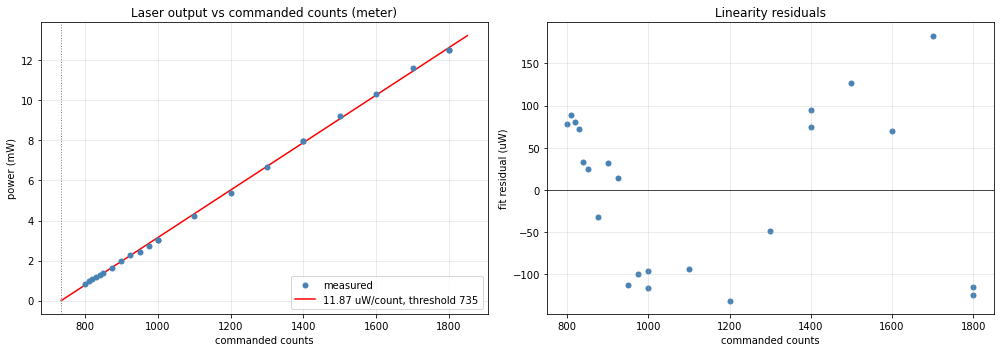

In [2]:
rows = []
with open(CAL_CSV) as f:
    rdr = csv.reader(f)
    next(rdr)                     # session-note comment line
    hdr = next(rdr)
    for r in rdr:
        d = dict(zip(hdr, r))
        p = d['power_mw']
        # two entries were typed with units and landed in the note column -- recover them
        if not p:
            if '16 uW' in d['note']:
                p = '0.016'
            elif '12.52 mW' in d['note']:
                p = '12.52'
        if not p:
            continue
        rows.append(dict(level=int(d['level_counts']), rb=float(d['readback_counts']),
                          p_mw=float(p), t0=float(d['t_set_unix']), t1=float(d['t_read_unix'])))
print(f"{len(rows)} usable calibration rows")

for r in rows:
    if abs(r['rb'] - r['level']) > 0.5:
        print(f"READBACK MISMATCH: commanded {r['level']}, readback {r['rb']:.0f} "
              f"(power {r['p_mw']} mW sits where {r['level']} should -- readback stale/wrong; "
              f"NB: 1550 also misbehaved in the July run)")

by_lvl = defaultdict(list)
for r in rows:
    by_lvl[r['level']].append(r['p_mw'])
print("\nRepeatability:")
for lvl, ps in sorted(by_lvl.items()):
    if len(ps) > 1:
        print(f"  {lvl:>5}: {ps}  spread {100*(max(ps)-min(ps))/np.mean(ps):.2f}%")
print(f"Dark (0 counts): {np.mean(by_lvl[0])*1e3:.1f} uW leakage, stable")

# Linear fit above threshold; exclude the readback-mismatch row from the fit
pts = [(r['level'], r['p_mw']) for r in rows if r['level'] >= 800 and abs(r['rb'] - r['level']) < 0.5]
L = np.array([x[0] for x in pts], float)
P = np.array([x[1] for x in pts], float)
MW_PER_COUNT, INTERCEPT = np.polyfit(L, P, 1)
THRESH_COUNTS = -INTERCEPT / MW_PER_COUNT
fit_resid = P - (MW_PER_COUNT * L + INTERCEPT)
print(f"\nP[mW] = {MW_PER_COUNT*1e3:.4f} uW/count * (counts - {THRESH_COUNTS:.0f})")
print(f"residual std {fit_resid.std():.3f} mW ({100*fit_resid.std()/P.mean():.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(L, P, s=25, color='steelblue', zorder=3, label='measured')
ll = np.linspace(THRESH_COUNTS, 1850, 100)
axes[0].plot(ll, MW_PER_COUNT * ll + INTERCEPT, 'r-', lw=1.5,
             label=f'{MW_PER_COUNT*1e3:.2f} uW/count, threshold {THRESH_COUNTS:.0f}')
axes[0].axvline(THRESH_COUNTS, color='gray', ls=':', lw=1)
axes[0].set_xlabel('commanded counts'); axes[0].set_ylabel('power (mW)')
axes[0].set_title('Laser output vs commanded counts (meter)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].scatter(L, fit_resid * 1e3, s=25, color='steelblue')
axes[1].axhline(0, color='black', lw=0.7)
axes[1].set_xlabel('commanded counts'); axes[1].set_ylabel('fit residual (uW)')
axes[1].set_title('Linearity residuals')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 2. PD Extraction and Clock Alignment
The DAQ PD trace is timestamped in cymac GPS, whose clock offset drifts. The offset is
found by sliding the CSV's known step timing against the PD trace and maximizing the
correlation between per-window PD medians and the measured powers.

In [3]:
t_list, y_list = [], []
with h5py.File(PD_FILE, 'r') as f:
    fs = float(f.attrs['sample_rate'])
    segs = f['segments/gps_start'][:].astype(np.float64)
    idxs = f['segments/index_start'][:].astype(np.int64)
    lens = f['segments/length'][:].astype(np.int64)
    dset = f['data']
    for gps0, ix, n in zip(segs, idxs, lens):
        y_seg = dset[ix:ix+n:1024].astype(np.float64)
        t_seg = gps0 + np.arange(len(y_seg)) * 1024 / fs
        t_list.append(t_seg); y_list.append(y_seg)
t = np.concatenate(t_list); y = np.concatenate(y_list)
o = np.argsort(t); t, y = t[o], y[o]
t_naive = t + GPS_UNIX_OFFSET   # cymac time as unix, before clock correction

powers = np.array([r['p_mw'] for r in rows])

def medians_for_offset(delta):
    med = np.full(len(rows), np.nan)
    std = np.full(len(rows), np.nan)
    for i, r in enumerate(rows):
        m = (t_naive >= r['t0'] + 25 + delta) & (t_naive <= r['t1'] - 2 + delta)
        if m.sum() > 10:
            med[i] = np.median(y[m])
            std[i] = y[m].std()
    return med, std

best = (None, -np.inf)
for delta in np.arange(-1200, 7200, 10.0):
    med, _ = medians_for_offset(delta)
    ok = np.isfinite(med)
    if ok.sum() < 20:
        continue
    c = np.corrcoef(powers[ok], med[ok])[0, 1]
    if c > best[1]:
        best = (delta, c)
for delta in np.arange(best[0] - 15, best[0] + 15, 1.0):
    med, _ = medians_for_offset(delta)
    ok = np.isfinite(med)
    c = np.corrcoef(powers[ok], med[ok])[0, 1]
    if c > best[1]:
        best = (delta, c)
CLOCK_OFFSET_S, corr = best
pd_med, pd_std = medians_for_offset(CLOCK_OFFSET_S)
print(f"cymac clock offset: +{CLOCK_OFFSET_S:.0f} s fast  (pattern correlation r = {corr:.5f})")
print(f"(history: +5836 s on 2026-06-03, +3072 s on 2026-07-02, +{CLOCK_OFFSET_S:.0f} s today)")

print(f"\n{'counts':>6} | {'power mW':>8} | {'PD median':>9} | {'PD std':>6}")
for r, m, s in zip(rows, pd_med, pd_std):
    print(f"{r['level']:>6} | {r['p_mw']:>8.4g} | {m:>9.2f} | {s:>6.2f}")

cymac clock offset: +4261 s fast  (pattern correlation r = 0.98531)
(history: +5836 s on 2026-06-03, +3072 s on 2026-07-02, +4261 s today)

counts | power mW | PD median | PD std
     0 |    0.016 |     16.27 | 106.84
  1800 |    12.52 |    239.77 |  35.23
  1700 |    11.64 |    172.54 |   6.41
  1600 |    10.34 |    185.92 |   3.98
  1550 |     9.88 |    188.06 |  19.46
  1500 |     9.21 |    148.17 |  15.43
  1400 |     7.97 |    123.95 |   9.95
  1300 |     6.66 |    112.48 |  28.15
  1200 |     5.39 |     83.94 |   2.48
  1100 |     4.24 |     80.02 |   9.33
  1000 |     3.03 |     63.46 |   5.69
   975 |     2.75 |     52.64 |   4.49
   950 |     2.44 |     46.05 |   2.25
   925 |     2.27 |     41.95 |   2.62
   900 |    1.991 |     39.23 |   2.34
   875 |     1.63 |     37.05 |   1.85
   850 |     1.39 |     36.44 |   1.82
   840 |     1.28 |     35.66 |   1.88
   830 |      1.2 |     34.70 |   1.94
   820 |     1.09 |     33.03 |   2.05
   810 |     0.98 |     30.97 |   2.00
  

## 3. PD vs True Power: the Wiggle
The meter says power is strictly monotonic in counts; the PD is not. The 1500–1800-count
zone shows non-monotonic PD readings (1700 below 1600; 1550 above 1600 — the July
anomaly, reproduced). An anchor linear fit quantifies both the useful average conversion
and the size of the systematic wiggle.

anchor fit: PD = 16.31 counts/mW * P + 11.0
wiggle systematic: residual std 11.6 PD counts (= 0.71 mW equivalent!)
PD at dark: 15.9 counts (16 uW real leakage light)


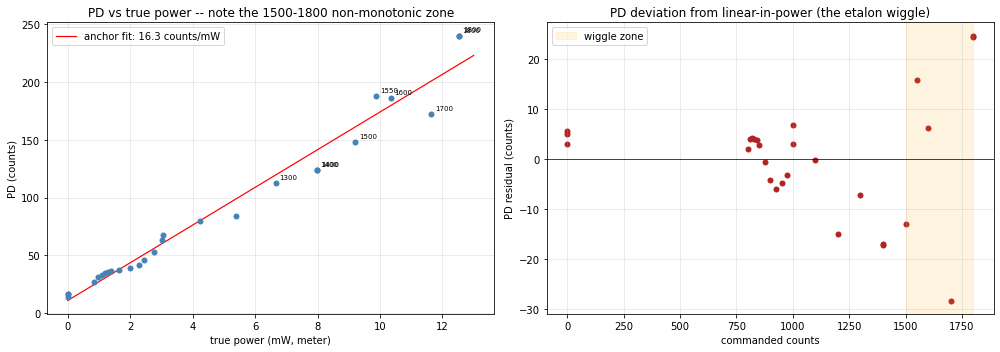

In [4]:
ok = np.isfinite(pd_med)
PD_PER_MW_ANCHOR, PD_DARK_FIT = np.polyfit(powers[ok], pd_med[ok], 1)
pd_resid = pd_med[ok] - (PD_PER_MW_ANCHOR * powers[ok] + PD_DARK_FIT)
lv_ok = np.array([r['level'] for r in rows])[ok]

print(f"anchor fit: PD = {PD_PER_MW_ANCHOR:.2f} counts/mW * P + {PD_DARK_FIT:.1f}")
print(f"wiggle systematic: residual std {pd_resid.std():.1f} PD counts "
      f"(= {pd_resid.std()/PD_PER_MW_ANCHOR:.2f} mW equivalent!)")
print(f"PD at dark: {np.mean([m for r, m in zip(rows, pd_med) if r['level'] == 0]):.1f} counts "
      f"(16 uW real leakage light)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(powers[ok], pd_med[ok], s=25, color='steelblue', zorder=3)
for pw, pm, lv in zip(powers[ok], pd_med[ok], lv_ok):
    if lv >= 1300:
        axes[0].annotate(str(int(lv)), (pw, pm), textcoords='offset points',
                         xytext=(4, 4), fontsize=7)
pp = np.linspace(0, 13, 50)
axes[0].plot(pp, PD_PER_MW_ANCHOR * pp + PD_DARK_FIT, 'r-', lw=1.2,
             label=f'anchor fit: {PD_PER_MW_ANCHOR:.1f} counts/mW')
axes[0].set_xlabel('true power (mW, meter)'); axes[0].set_ylabel('PD (counts)')
axes[0].set_title('PD vs true power -- note the 1500-1800 non-monotonic zone')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(lv_ok, pd_resid, s=25, color='firebrick')
axes[1].axhline(0, color='black', lw=0.7)
axes[1].axvspan(1500, 1800, alpha=0.12, color='orange', label='wiggle zone')
axes[1].set_xlabel('commanded counts'); axes[1].set_ylabel('PD residual (counts)')
axes[1].set_title('PD deviation from linear-in-power (the etalon wiggle)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Reproducibility vs the July Run
PD plateau levels from the July step-down at the same commanded counts (from
`laser_stepdown_steps.csv`), compared to today. Matching levels mean the PD map is
stable there; mismatches mean the wiggle pattern moved (mode-hop / etalon drift), so a
retroactive per-level PD correction is NOT trustworthy in the wiggle zone.

In [5]:
july = {}
with open(STEPS_CSV) as f:
    for row in csv.DictReader(f):
        if row['counts']:
            july[int(float(row['counts']))] = float(row['pd_level'])

today = {}
for r, m in zip(rows, pd_med):
    if np.isfinite(m):
        today.setdefault(r['level'], []).append(m)

print(f"{'counts':>6} | {'PD July':>8} | {'PD today':>8} | {'diff %':>7}")
for lvl in sorted(july, reverse=True):
    if lvl in today:
        td = np.mean(today[lvl])
        print(f"{lvl:>6} | {july[lvl]:>8.1f} | {td:>8.1f} | {100*(td-july[lvl])/july[lvl]:>+7.1f}")
print("\n1800 / 1550 / 1200 / 1000 reproduce well; 1300-1700 shifted by ~10-40% -- the")
print("wiggle pattern is not stable week-to-week at those levels.")

counts |  PD July | PD today |  diff %
  1800 |    240.2 |    240.0 |    -0.1
  1600 |    167.3 |    185.9 |   +11.1
  1550 |    186.2 |    188.1 |    +1.0
  1500 |    160.0 |    148.2 |    -7.4
  1400 |    114.5 |    124.0 |    +8.3
  1300 |    134.7 |    112.5 |   -16.5
  1200 |     84.0 |     83.9 |    -0.1
  1000 |     67.2 |     65.5 |    -2.6

1800 / 1550 / 1200 / 1000 reproduce well; 1300-1700 shifted by ~10-40% -- the
wiggle pattern is not stable week-to-week at those levels.


## 5. Mechanism and Fix Plan (pending lab discussion)
**Filter stack:** light → notch (interference) filter → reflective ND → photodiode.

**Mechanism — etalon fringes + diode wavelength motion.** The reflective ND attenuates
via a high-reflectivity flat coating, and it sits between two other flat reflective-ish
surfaces, forming two air-gap etalons:
1. **notch ↔ ND** (few % residual notch reflection against the ND's high-R face):
   fringe spacing ~0.04 nm for a ~5 mm gap — a mode hop (0.1–0.3 nm) sweeps several
   fringes; the fringe phase also moves with ~0.3 µm of mount thermal expansion,
   explaining week-scale non-reproducibility.
2. **ND ↔ PD window** (~4% window reflection against the ND coating): visibility of
   order tens of percent.

The diode's wavelength moves with drive current (continuously plus mode hops), so
ramping current converts wavelength motion into PD transmission wiggles while the true
output power stays smooth — exactly what Sections 1 and 3 show. The notch filter is a
second suspect if the ~660 nm operating wavelength sits near its passband edge (spec to
be checked). **Same mechanism at fixed current:** slow thermal wavelength drift walks a
fringe and changes the PD reading with no real power change — a concrete candidate for
the anti-correlated frequency wander seen on the 1300-count plateau
(`laser_stepdown_forward_model.ipynb` Section 6.8).

**Fix checklist (to discuss before acting):**
1. Tilt the reflective ND a few degrees (breaks both cavities at once; dump the
   rejected beam safely, not back along the input path).
2. Small tilt on the notch at a different angle; check its center/width spec vs the
   actual ~660 nm operating wavelength (tilting shifts an interference filter's
   passband slightly blueward).
3. Diagnostic while tilting: sit at ~1600 counts with the meter watching total power —
   the element whose tilt moves the PD ~10% while the meter holds still is the offender.
4. If interference-filter ripple persists: replace the notch with absorptive colored
   glass (e.g. RG610/RG630 longpass) for ambient-light rejection.
5. After any change: rerun `lab_utils/laser_power_calibration.py` (~40 min) to certify
   the new PD ↔ mW curve.

In [6]:
# Machine-readable summary for downstream notebooks
with open(OUT_SUMMARY, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['# laser calibration summary, session 2026-07-20 (see pd_calibration.ipynb)'])
    w.writerow(['constant', 'value', 'note'])
    w.writerow(['mw_per_count', f'{MW_PER_COUNT:.6e}', 'linear slope above threshold'])
    w.writerow(['threshold_counts', f'{THRESH_COUNTS:.1f}', 'laser threshold'])
    w.writerow(['pd_per_mw_anchor', f'{PD_PER_MW_ANCHOR:.3f}',
                'average conversion; +/-12 counts wiggle systematic, worst 1500-1800'])
    w.writerow(['pd_dark_counts', '15.9', 'at 16 uW leakage, laser offset 0'])
    w.writerow(['cymac_clock_offset_s', f'{CLOCK_OFFSET_S:.0f}', 'cymac fast, this session'])
    w.writerow([])
    w.writerow(['level_counts', 'power_mw_measured', 'pd_median', 'pd_std'])
    for r, m, s in zip(rows, pd_med, pd_std):
        w.writerow([r['level'], r['p_mw'],
                    f'{m:.2f}' if np.isfinite(m) else '', f'{s:.2f}' if np.isfinite(s) else ''])
print(f"wrote {OUT_SUMMARY}")

print("\n" + "=" * 72)
print("CALIBRATION SUMMARY")
print("=" * 72)
print(f"counts -> mW : P = {MW_PER_COUNT*1e3:.3f} uW/count * (counts - {THRESH_COUNTS:.0f}),  "
      f"resid {fit_resid.std()*1e3:.0f} uW")
print(f"PD -> mW     : {PD_PER_MW_ANCHOR:.1f} counts/mW anchor, +/-{pd_resid.std():.0f} counts wiggle")
print(f"PD dark      : ~16 counts (16 uW leakage)")
print(f"clock        : cymac +{CLOCK_OFFSET_S:.0f} s fast")

wrote /Users/mollywatts/Desktop/VSCode/decay_sail/analysis/laser_calibration/laser_calibration_summary_20260720.csv

CALIBRATION SUMMARY
counts -> mW : P = 11.872 uW/count * (counts - 735),  resid 93 uW
PD -> mW     : 16.3 counts/mW anchor, +/-12 counts wiggle
PD dark      : ~16 counts (16 uW leakage)
clock        : cymac +4261 s fast
